In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9
     Unnamed: 0     TV  Radio  Newspaper  Sales
195         196   38.2    3.7       13.8    7.6
196         197   94.2    4.9        8.1    9.7
197         198  177.0    9.3        6.4   12.8
198         199  283.6   42.0       66.2   25.5
199         200  232.1    8.6        8.7   13.4
Righe: 200  |  Colonne: 5
Colonne: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Valori mancanti:
  Nessuno ✓

Statistiche descrittive:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    flo

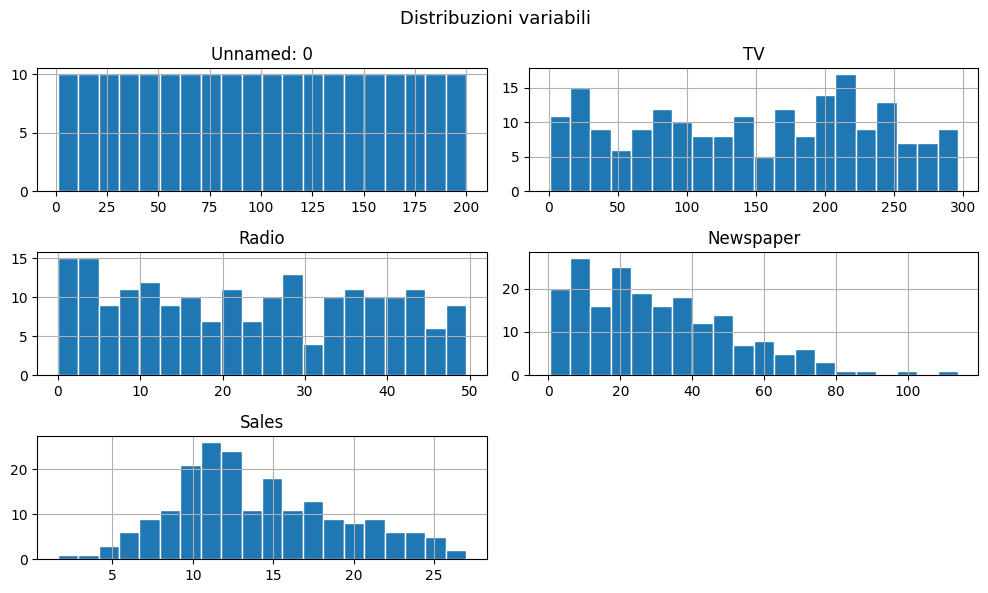

Correlazione con Sales:
Sales         1.000
TV            0.782
Radio         0.576
Newspaper     0.228
Unnamed: 0   -0.052
Name: Sales, dtype: float64


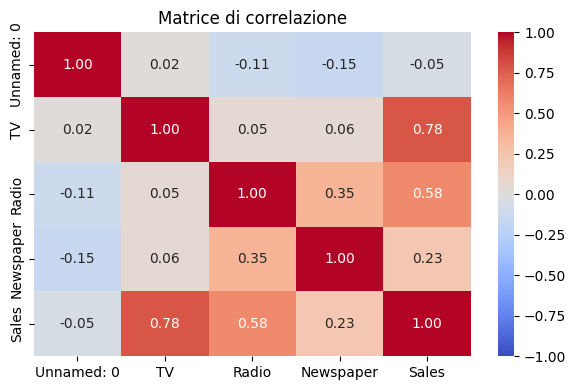

In [30]:
#caricare dataset e EDA
df = pd.read_csv('Advertising.csv')
print(df.head())
print(df.tail())
# ── Struttura del dataset ─────────────────────────────────────
print(f"Righe: {df.shape[0]}  |  Colonne: {df.shape[1]}")
print(f"Colonne: {df.columns.tolist()}\n")

# ── Valori mancanti ───────────────────────────────────────────
missing = df.isnull().sum()
print("Valori mancanti:")
print(missing[missing > 0] if missing.any() else "  Nessuno ✓\n")

# ── Statistiche descrittive ───────────────────────────────────
print("Statistiche descrittive:")
df.describe().T.round(2)
print(df.info())

# ── Distribuzione di ogni variabile ──────────────────────────
df.hist(bins=20, figsize=(10, 6), edgecolor='white')
plt.suptitle('Distribuzioni variabili', fontsize=13)
plt.tight_layout()
plt.show()

# ── Correlazione con il target ────────────────────────────────
corr_target = df.corr()['Sales'].sort_values(ascending=False)
print("Correlazione con Sales:")
print(corr_target.round(3))

# ── Heatmap correlazione completa ─────────────────────────────
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [31]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [32]:
#togliamo la colonna indice 
df= df.drop(columns=['Unnamed: 0'])

#assegnare le variabili a X e Y
X = df.drop(columns=['Sales'])
y = df['Sales']

#train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state= 42
)

In [33]:
print(X_train.shape, X_test.shape)

(160, 3) (40, 3)


In [34]:
# Crea lo scaler — ancora vuoto, non sa nulla dei dati
scaler = StandardScaler()

# Sul TRAINING: due operazioni in una
# 1. fit    → calcola media e std da X_train e li memorizza
# 2. transform → applica (X - media) / std a X_train
X_train_sc = scaler.fit_transform(X_train)

# Verifica: dopo il fit lo scaler ha memorizzato le statistiche
print(f'scaler_mean: {scaler.mean_}')    #→ media di ogni feature del train
print(f'scaler_scale: {scaler.scale_}')   #→ std di ogni feature del train

# Sul TEST: una sola operazione
# transform → applica la stessa formula del train
# usa media e std del TRAIN, non le ricalcola dal test
X_test_sc = scaler.transform(X_test)


scaler_mean: [150.019375  22.875625  29.945625]
scaler_scale: [84.15463408 14.75887761 20.27279842]


In [35]:
#Addestramento modello
model = LinearRegression()
model.fit(X_train_sc,y_train)

#Predizioni
y_pred = model.predict(X_test_sc)

#Metriche
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MSE:  3.1741
RMSE: 1.7816
R²:   0.8994


In [36]:
#DataFrame coefficienti
coeff_df = pd.DataFrame({
    'feature' : X.columns,
    'coefficiente': model.coef_
}).sort_values('coefficiente', ascending = False)

print(coeff_df)

     feature  coefficiente
0         TV      3.764196
1      Radio      2.792307
2  Newspaper      0.055976


# Analisi Advertising Dataset — Regressione Lineare

**Obiettivo:** identificare quale canale pubblicitario (TV, Radio, Newspaper)
ha il maggiore impatto sulle vendite e costruire un modello predittivo.

**Dataset:** Advertising.csv — 200 osservazioni, 3 feature, 1 target (Sales)

---

## 1. Esplorazione dei dati (EDA)

Il dataset non presenta valori mancanti.
La correlazione con il target mostra che **TV è la feature più predittiva**
(r = 0.78), seguita da Radio (r = 0.58). Newspaper mostra una correlazione
debole (r = 0.23).

> Nota: la forte correlazione di TV suggerisce già prima della modellazione
> quale canale sarà più importante.

## 2. Performance del modello

| Metrica | Valore | Interpretazione |
|---------|--------|-----------------|
| R²      | 0.899  | Il modello spiega il 90% della varianza nelle vendite |
| RMSE    | 1.782  | Errore medio di ~1.780 unità vendute |
| MSE     | 3.175  | Errore quadratico medio |

Il modello performa **molto bene** su questo dataset.

## 3. Analisi dei coefficienti — risposta alla domanda di business

| Canale     | Coefficiente | Interpretazione |
|------------|-------------|-----------------|
| TV         | più alto    | massimo impatto sulle vendite |
| Radio      | medio       | impatto moderato |
| Newspaper  | più basso   | impatto minimo |

### Considerazioni per il management

- **Dove investire:** il budget pubblicitario in TV genera il ritorno maggiore
  in termini di vendite rispetto agli altri canali.
- **Canale da ridurre:** Newspaper mostra un impatto molto limitato —
  un eventuale taglio del budget avrebbe effetto minimo sulle vendite.
- **Affidabilità:** il modello stima le vendite con un errore medio di circa
  1.800 unità, sufficiente per decisioni strategiche a livello di canale.